# ST2195 Assignment 8.2
## G7 Bilateral Trade Network (2024)

This notebook analyses the latest bilateral trade flows among the G7 countries using NetworkX and three network visualisations.

In [1]:
# ==========================================
# Assignment 8.2 - G7 Trade Network
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

%matplotlib inline

In [4]:
# Load the 2024 G7 exports data
trade_2024 = pd.read_excel("g7_exports_2024.xlsx")

# Display the first five rows
trade_2024.head()

,REF_AREA,CA,DE,FR,GB,IT,JP,US
0,CA,NaN,4933.0,3213.0,20628.0,2382.0,10918.0,435114.0
1,DE,13956.0,NaN,125670.0,86798.0,87382.0,23313.0,174482.0
2,FR,4264.0,83435.0,NaN,39475.0,51861.0,9892.0,50937.0
3,GB,8880.0,40941.0,29778.0,NaN,11760.0,9307.0,73688.0
4,IT,6640.0,76817.0,67350.0,29671.0,NaN,8908.0,70075.0


In [6]:
# Display column names
print("Columns:")
print(trade_2024.columns.tolist())

print("\nDataset information:")
trade_2024.info()

Columns:
['REF_AREA', 'CA', 'DE', 'FR', 'GB', 'IT', 'JP', 'US']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   REF_AREA  7 non-null      object 
 1   CA        6 non-null      float64
 2   DE        6 non-null      float64
 3   FR        6 non-null      float64
 4   GB        6 non-null      float64
 5   IT        6 non-null      float64
 6   JP        6 non-null      float64
 7   US        6 non-null      float64
dtypes: float64(7), object(1)
memory usage: 580.0+ bytes


In [7]:
# ==========================================
# Convert the trade matrix into long format
# ==========================================

trade_2024_long = trade_2024.melt(
    id_vars="REF_AREA",
    var_name="Importer",
    value_name="Exports"
)

trade_2024_long.head(10)

,REF_AREA,Importer,Exports
0,CA,CA,NaN
1,DE,CA,13956.0
2,FR,CA,4264.0
3,GB,CA,8880.0
4,IT,CA,6640.0
5,JP,CA,11166.0
6,US,CA,349398.0
7,CA,DE,4933.0
8,DE,DE,NaN
9,FR,DE,83435.0


In [8]:
# ==========================================
# Rename columns and remove missing values
# ==========================================

trade_2024_long = trade_2024_long.rename(
    columns={"REF_AREA": "Exporter"}
)

# Remove missing values (countries do not export to themselves)
trade_2024_long = trade_2024_long.dropna()

# Preview the cleaned edge list
trade_2024_long.head(10)

,Exporter,Importer,Exports
1,DE,CA,13956.0
2,FR,CA,4264.0
3,GB,CA,8880.0
4,IT,CA,6640.0
5,JP,CA,11166.0
6,US,CA,349398.0
7,CA,DE,4933.0
9,FR,DE,83435.0
10,GB,DE,40941.0
11,IT,DE,76817.0


## Create the Network Graph

The cleaned edge list is converted into a directed network graph using NetworkX. Each country is represented as a node, while each export flow is represented as a directed edge weighted by its export value.

In [9]:
# ==========================================
# Create the directed trade network
# ==========================================

G_2024 = nx.from_pandas_edgelist(
    trade_2024_long,
    source="Exporter",
    target="Importer",
    edge_attr="Exports",
    create_using=nx.DiGraph()
)

print(f"Number of nodes: {G_2024.number_of_nodes()}")
print(f"Number of edges: {G_2024.number_of_edges()}")

Number of nodes: 7
Number of edges: 42


In [11]:
# ==========================================
# Network visualisation settings
# ==========================================

options = {
    "node_color": "lightblue",
    "edge_color": "lightblue",
    "node_size": 1800,
    "width": 1.5,
    "with_labels": True,
}

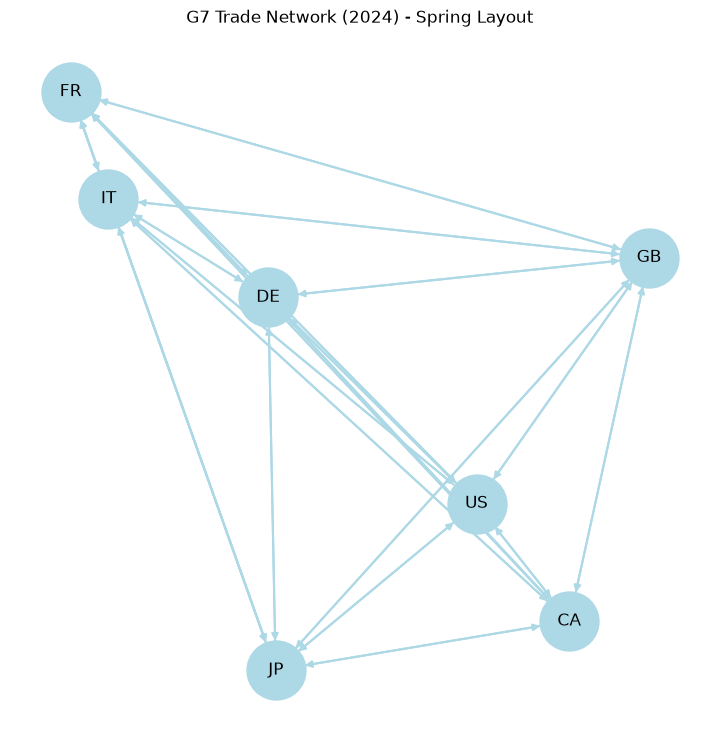

In [12]:
# ==========================================
# Spring Layout
# ==========================================

plt.figure(figsize=(7,7))

pos = nx.spring_layout(G_2024, seed=42)

nx.draw(G_2024, pos, **options)

plt.title("G7 Trade Network (2024) - Spring Layout")
plt.axis("off")
plt.show()

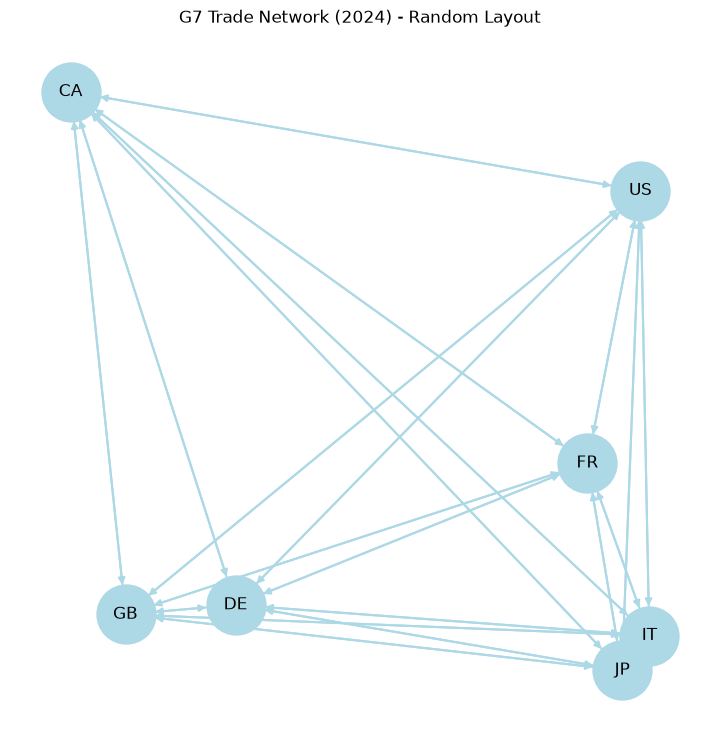

In [13]:
# ==========================================
# Random Layout
# ==========================================

plt.figure(figsize=(7,7))

pos = nx.random_layout(G_2024)

nx.draw(G_2024, pos, **options)

plt.title("G7 Trade Network (2024) - Random Layout")
plt.axis("off")
plt.show()

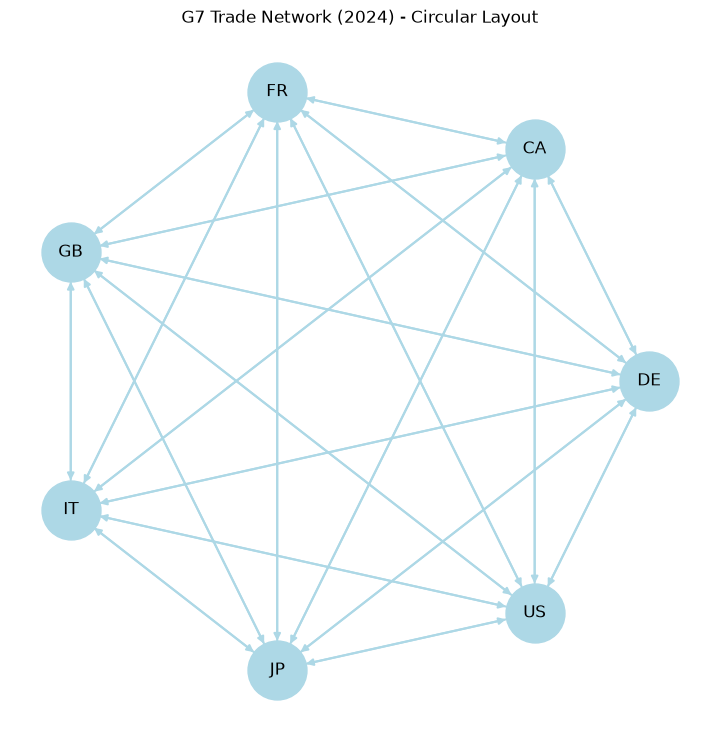

In [14]:
# ==========================================
# Circular Layout
# ==========================================

plt.figure(figsize=(7,7))

pos = nx.circular_layout(G_2024)

nx.draw(G_2024, pos, **options)

plt.title("G7 Trade Network (2024) - Circular Layout")
plt.axis("off")
plt.show()